<img src="../../images/arm_logo.png" width=500 alt="ARM Logo"></img>

# Decadal Near-Surface Turbulent Flux Measurements from ARM
---

## Overview

Within this notebook, we will cover:
1. History of ARM's near-surface turbulent flux observations
1. Introduction to the Energy Balance Bowen Ratio (EBBR) and Eddy Covariance (EC) methods
1. Comparison of Sensible and Latent Heat Fluxes from these methods for 2015 to 2023 period at SGP

## Prerequisites
| Concepts | Importance | Notes |
| --- | --- | --- |
| [ACT Basics](../act/ACT-Basics-BNF.ipynb) | Helpful | Basic features |
| [Matplotlib Basics](https://foundations.projectpythia.org/core/matplotlib/) | Helpful | Basic plotting |
| [NumPy Basics](https://foundations.projectpythia.org/core/numpy/) | Helpful | Basic arrays |
| [Xarray Basics](https://foundations.projectpythia.org/core/xarray/) | Helpful | Multi-dimensional arrays |

- **Time to learn**: 15 minutes
---

## History of ARM's Near-Surface Turbulent Flux Observations at SGP

## Energy Balence Bowen Ratio (EBBR) and Eddy Covariance (EC) Methods

## EBBR and EC Data Ingest

From Sullivan et al. (2025), the timelines for the EBBR and EC products:
- ECOR system {2015 - 2019}
- ECOR with Smartflux {2019 - 2026}
- EBBR {2015 - 2023}

In [5]:
import glob
import matplotlib.pyplot as plt

import act

In [6]:
from zoneinfo import ZoneInfo

In [7]:
# Define the path to the EBBR, ECOR, and EC datasets
base_path = "/Users/jrobrien/ARM/2026-Summer-School/"
ebbr_files = sorted(glob.glob(base_path + "sgp30ebbrE39.b1/*.nc"))
ecor_files = sorted(glob.glob(base_path + "sgp30ecorE39.b1/*.cdf"))
ecor_sf_files = sorted(glob.glob(base_path + "sgpecorsfE39.b1/*.nc"))

In [12]:
ds_ebbr = act.io.read_arm_netcdf(ebbr_files,
                                 keep_variables=["sensible_heat_flux", "latent_heat_flux", "temp_air_top", "wspd_vec_mean", "wdir_vec_mean"],
                                 cleanup_qc=True)

In [14]:
ds_ecor = act.io.read_arm_netcdf(ecor_files, 
                                 keep_variables=["h", "lv_e", "wind_dir", "wind_spd", "temp_irga"],
                                 cleanup_qc=True)

In [15]:
ds_ecor_sf = act.io.read_arm_netcdf(ecor_sf_files, 
                                    keep_variables=["sensible_heat_flux", "latent_flux", "wind_direction_from_north", "mean_wind", "air_temperature"],
                                    cleanup_qc=True)

/Users/jrobrien/.vscode-micromamba/envs/arm-summer-school-2026-dev/lib/python3.11/site-packages/act/io/arm.py:155: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  ds = xr.open_mfdataset(filenames, **kwargs)
/Users/jrobrien/.vscode-micromamba/envs/arm-summer-school-2026-dev/lib/python3.11/site-packages/act/io/arm.py:155: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set com

## Sensible and Latent Heat Flux Diel Cycles

In [18]:
## --- Clean up the datasets ---
ds_ecor_corr = ds_ecor.where(ds_ecor['h'] > -200).where(ds_ecor['h'] < 2000)
ds_ebbr_corr = ds_ebbr.where(ds_ebbr['sensible_heat_flux'] > -200).where(ds_ebbr['sensible_heat_flux'] < 2000)

In [19]:
# --- Convert to Local time for Diel Cycles ---
# Create Timezone-aware index, converting to local time
chicago_tz = ZoneInfo("America/Chicago")
ecor_sf_index = ds_ecor_sf.indexes["time"].tz_localize("UTC").tz_convert(chicago_tz)
ecor_index = ds_ecor_corr.indexes["time"].tz_localize("UTC").tz_convert(chicago_tz)
ebbr_index = ds_ebbr_corr.indexes["time"].tz_localize("UTC").tz_convert(chicago_tz)

# Assign the new index back to the xarray object
ds_ecor_sf = ds_ecor_sf.assign_coords(time=ecor_sf_index)
ds_ecor_corr = ds_ecor_corr.assign_coords(time=ecor_index)
ds_ebbr_corr = ds_ebbr_corr.assign_coords(time=ebbr_index)

# Now remove the timezone aware information for groupby options
# Will still be in local time!
ds_ecor_sf["time"] = ds_ecor_sf["time"].data.tz_localize(None)
ds_ecor_corr["time"] = ds_ecor_corr["time"].data.tz_localize(None)
ds_ebbr_corr["time"] = ds_ebbr_corr["time"].data.tz_localize(None)

In [32]:
ds_ebbr_corr

<xarray.Dataset> Size: 4MB
Dimensions:             (time: 139116)
Coordinates:
  * time                (time) datetime64[ns] 1MB 2015-12-31T18:00:00 ... 202...
Data variables:
    temp_air_top        (time) float32 556kB dask.array<chunksize=(48,), meta=np.ndarray>
    latent_heat_flux    (time) float32 556kB dask.array<chunksize=(48,), meta=np.ndarray>
    sensible_heat_flux  (time) float32 556kB dask.array<chunksize=(48,), meta=np.ndarray>
    wspd_vec_mean       (time) float32 556kB dask.array<chunksize=(48,), meta=np.ndarray>
    wdir_vec_mean       (time) float32 556kB dask.array<chunksize=(48,), meta=np.ndarray>
Attributes: (12/23)
    command_line:                ebbr_ingest -s sgp -f E39
    Conventions:                 ARM-1.0
    process_version:             ingest-ebbr-10.0-0.el6
    dod_version:                 30ebbr-b1-3.0
    input_source:                /data/collection/sgp/sgpebbrE39.00/145160640...
    site_id:                     sgp
    ...                          ...
    AEM_description:             Automatic Exchange Mechanism
    history:                     created by user dsmgr on machine ruby at 201...
    _file_dates:                 ['20160101', '20160102', '20160103', '201601...
    _file_times:                 ['000000', '000000', '000000', '000000', '00...
    _datastream:                 sgp30ebbrE39.b1
    _arm_standards_flag:         1

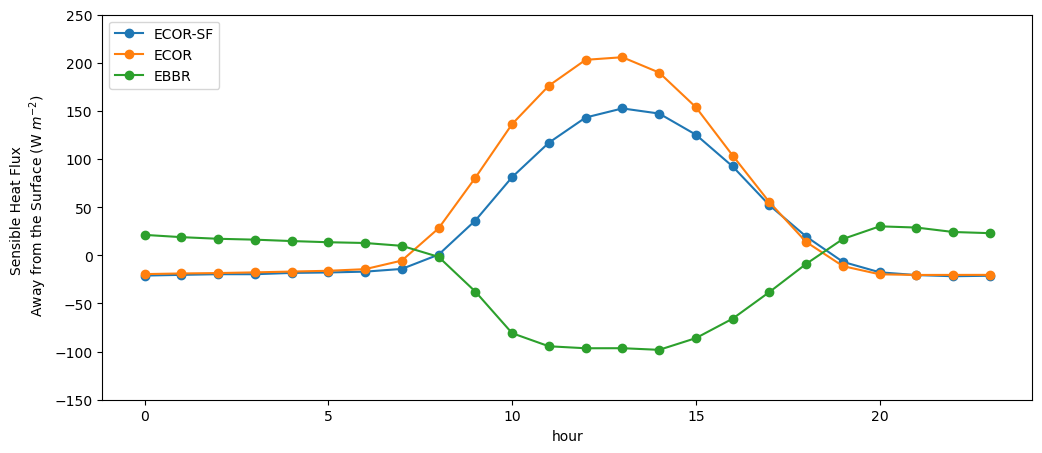

In [29]:
# --- Plot Diel Cycle using xarray grouby function ---
fig, axarr = plt.subplots(1, 1, figsize=(12, 5))

ds_ecor_sf['sensible_heat_flux'].groupby(ds_ecor_sf['time'].dt.hour).mean().plot(marker="o",
                                                                                 ax=axarr,
                                                                                 label="ECOR-SF")
ds_ecor_corr['h'].groupby(ds_ecor_corr['time'].dt.hour).mean().plot(marker="o",
                                                                    ax=axarr,
                                                                    label="ECOR")
ds_ebbr_corr['sensible_heat_flux'].groupby(ds_ebbr_corr['time'].dt.hour).mean().plot(marker="o",
                                                                                         ax=axarr,
                                                                                         label="EBBR")

axarr.set_ylabel(f"Sensible Heat Flux \n Away from the Surface (W $m^{{-2}}$)")
axarr.set_ylim([-150, 250])
axarr.legend(loc="upper left")

## Diel Cycles per Crop Type

From Sullivan et al. (2025), at Southern Great Plains Extended Site (E39):
- southerly (100-260&deg;) fetch contains the cropland footprint
- northerly (0-80 and 280-360&deg;) fetch contains the ungrazed grass footprint

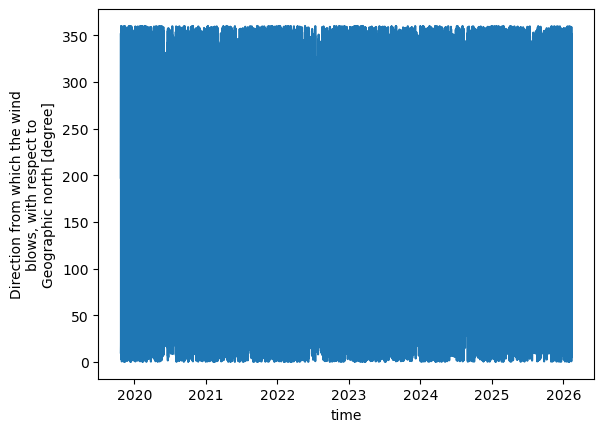

In [ ]:
ecor_sf_crop = ds_ecor_sf.where((ds_ecor_sf['wind_direction_from_north'] >= 100) & (ds_ecor_sf['wind_direction_from_north'] <= 260), drop=True)

## Decadal Comparison Across Land Surface Types